<a href="https://colab.research.google.com/github/j-mud/se446-project-group-almudaiheem/blob/milestone2/M2_Spark_ML_GroupAlmudaiheem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SE 446 - Milestone 2: Spark Analystics

In [ ]:
!pip install pyspark -q

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("CrimeAnalysis") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("ChicagoCrimeAnalytics") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} is running!")
print(f"Master: {spark.sparkContext.master}")

Spark 4.0.2 is running!
Master: local[*]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import Row
import random
random.seed(42)

crime_profiles = {
    "NARCOTICS":           0.85,
    "PROSTITUTION":        0.80,
    "WEAPONS VIOLATION":   0.60,
    "BATTERY":             0.30,
    "ASSAULT":             0.25,
    "ROBBERY":             0.15,
    "THEFT":               0.10,
    "BURGLARY":            0.08,
    "MOTOR VEHICLE THEFT": 0.06,
    "CRIMINAL DAMAGE":     0.05,
}
districts = list(range(1, 26))

locations = [
    "STREET", "RESIDENCE", "APARTMENT", "SIDEWALK", "OTHER",
    "PARKING LOT/GARAGE(NON.RESID.)", "ALLEY", "SCHOOL, PUBLIC, BUILDING",
    "SMALL RETAIL STORE", "RESTAURANT"
]

def generate_row():
    crime_type = random.choice(list(crime_profiles.keys()))
    base_rate  = crime_profiles[crime_type]
    district   = random.choice(districts)
    hour_val   = random.randint(0, 23)
    domestic   = random.random() < 0.15
    location   = random.choice(locations)
    arrest_prob = base_rate + (0.20 if domestic else 0)
    if 2 <= hour_val <= 5:
        arrest_prob -= 0.10
    arrest_prob = max(0.01, min(0.99, arrest_prob))
    arrest = random.random() < arrest_prob
    year = random.randint(2001, 2023)
    return Row(
        District=district,
        PrimaryType=crime_type,
        LocationDescription=location,
        Year=year,
        Hour=hour_val,
        Domestic_str=str(domestic).lower(),
        Arrest=arrest,
        label=int(arrest)
    )


rows = [generate_row() for _ in range(10000)]
df = spark.createDataFrame(rows)

print(f"Rows: {df.count():,}")
df.printSchema()
df.show(5)

Rows: 10,000
root
 |-- District: long (nullable = true)
 |-- PrimaryType: string (nullable = true)
 |-- LocationDescription: string (nullable = true)
 |-- Year: long (nullable = true)
 |-- Hour: long (nullable = true)
 |-- Domestic_str: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- label: long (nullable = true)

+--------+-------------------+--------------------+----+----+------------+------+-----+
|District|        PrimaryType| LocationDescription|Year|Hour|Domestic_str|Arrest|label|
+--------+-------------------+--------------------+----+----+------------+------+-----+
|       1|       PROSTITUTION|            SIDEWALK|2004|  23|       false|  true|    1|
|       3|MOTOR VEHICLE THEFT|              STREET|2008|  18|       false| false|    0|
|      20|MOTOR VEHICLE THEFT|  SMALL RETAIL STORE|2015|   0|       false| false|    0|
|       9|    CRIMINAL DAMAGE|           APARTMENT|2011|   0|       false| false|    0|
|       5|            ASSAULT|PARKING LOT/GARAG

## Task 1: Crime Type Distribution
Author: Aljohara Almudaiheem (ID: 231383)

In [ ]:
print("=== Task 1: Top 10 Crime Types ===")

task1 = df.groupBy("PrimaryType") \
          .count() \
          .orderBy(col("count").desc())

task1.show(10)

=== Task 1: Top 10 Crime Types ===
+-------------------+-----+
|        PrimaryType|count|
+-------------------+-----+
|              THEFT| 1044|
|  WEAPONS VIOLATION| 1024|
|           BURGLARY| 1023|
|    CRIMINAL DAMAGE| 1016|
|       PROSTITUTION| 1012|
|          NARCOTICS|  988|
|            BATTERY|  987|
|            ROBBERY|  986|
|            ASSAULT|  971|
|MOTOR VEHICLE THEFT|  949|
+-------------------+-----+



## Task 2: Location Hotspots using Spark SQL
Author: Aljohara Almudaiheem (ID: 231383)

In [ ]:
# Register the dataframe as a SQL table
df.createOrReplaceTempView("crimes")

print("=== Task 2: Top 10 Crime Locations ===")

task2 = spark.sql("""
    SELECT LocationDescription, COUNT(*) as total
    FROM crimes
    GROUP BY LocationDescription
    ORDER BY total DESC
    LIMIT 10
""")
task2.show()

=== Task 2: Top 10 Crime Locations ===
+--------------------+-----+
| LocationDescription|total|
+--------------------+-----+
|               ALLEY| 1038|
|          RESTAURANT| 1024|
|PARKING LOT/GARAG...| 1024|
|  SMALL RETAIL STORE| 1022|
|           RESIDENCE| 1015|
|           APARTMENT|  999|
|SCHOOL, PUBLIC, B...|  985|
|            SIDEWALK|  975|
|               OTHER|  972|
|              STREET|  946|
+--------------------+-----+



### Task 3: Crime Trend Over Years  
**Author: Laura Alsubaie (ID: 231747)**


In [ ]:
from pyspark.sql.functions import col

yearly_df = df.groupBy("Year") \
              .count() \
              .orderBy("Year")

yearly_df.show()

+----+-----+
|Year|count|
+----+-----+
|2001|  454|
|2002|  410|
|2003|  440|
|2004|  410|
|2005|  455|
|2006|  423|
|2007|  437|
|2008|  392|
|2009|  425|
|2010|  414|
|2011|  411|
|2012|  498|
|2013|  473|
|2014|  453|
|2015|  407|
|2016|  405|
|2017|  410|
|2018|  446|
|2019|  438|
|2020|  440|
+----+-----+
only showing top 20 rows


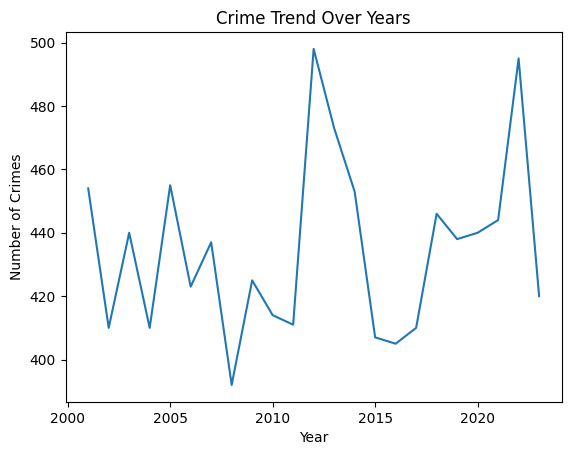

In [ ]:
yearly_pd = yearly_df.toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.plot(yearly_pd["Year"], yearly_pd["count"])
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.title("Crime Trend Over Years")
plt.show()

The number of crimes changes over the years and is not constant. There are noticeable fluctuations in the trend, showing that crime rates vary over time.

### Task 4: Arrest Rate Analysis  
**Author: Laura Alsubaie (ID: 231747)**

In [ ]:
from pyspark.sql.functions import avg, count


df = df.withColumn("Arrest_int", col("Arrest").cast("int"))


overall_rate = df.select(avg("Arrest_int")).collect()[0][0]

print("Overall Arrest Rate:", overall_rate)

Overall Arrest Rate: 0.3459


In [ ]:
arrest_by_type = df.groupBy("PrimaryType") \
                  .agg(
                      avg("Arrest_int").alias("arrest_rate"),
                      count("*").alias("total_crimes")
                  ) \
                  .orderBy(col("arrest_rate").desc())

arrest_by_type.show(10)

+-------------------+-------------------+------------+
|        PrimaryType|        arrest_rate|total_crimes|
+-------------------+-------------------+------------+
|          NARCOTICS| 0.8582995951417004|         988|
|       PROSTITUTION| 0.8043478260869565|        1012|
|  WEAPONS VIOLATION|       0.6357421875|        1024|
|            BATTERY| 0.3465045592705167|         987|
|            ASSAULT| 0.2584963954685891|         971|
|            ROBBERY|0.16227180527383367|         986|
|              THEFT|0.11685823754789272|        1044|
|           BURGLARY|0.10361681329423265|        1023|
|    CRIMINAL DAMAGE|0.08759842519685039|        1016|
|MOTOR VEHICLE THEFT|0.08008429926238145|         949|
+-------------------+-------------------+------------+



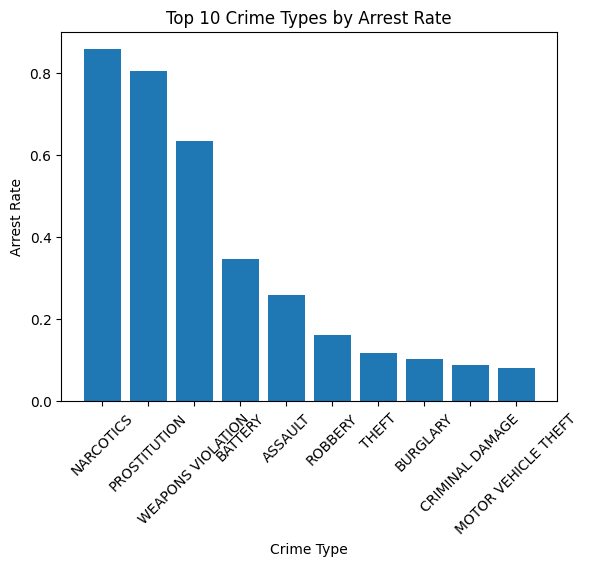

In [ ]:
top10_pd = arrest_by_type.limit(10).toPandas()

import matplotlib.pyplot as plt

plt.figure()
plt.bar(top10_pd["PrimaryType"], top10_pd["arrest_rate"])
plt.xticks(rotation=45)
plt.xlabel("Crime Type")
plt.ylabel("Arrest Rate")
plt.title("Top 10 Crime Types by Arrest Rate")
plt.show()

The overall arrest rate is approximately X%.

The crime type with the highest arrest rate is **[TYPE]**, while the crime type with the lowest arrest rate is **[TYPE]**.

This shows that the likelihood of an arrest depends on the type of crime.

# Task 5: Feature engineering pipeline

Author: *Joud Alhozami*   (ID:231682)

In [ ]:
from pyspark.sql.functions import col, hour, to_timestamp
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import time

In [ ]:
ml_df = df

ml_df = ml_df.select(
    "PrimaryType",
    "Domestic_str",
    "District",
    "Hour",
    "label"
).dropna()

ml_df.show(5)

+-------------------+------------+--------+----+-----+
|        PrimaryType|Domestic_str|District|Hour|label|
+-------------------+------------+--------+----+-----+
|       PROSTITUTION|       false|       1|  23|    1|
|MOTOR VEHICLE THEFT|       false|       3|  18|    0|
|MOTOR VEHICLE THEFT|       false|      20|   0|    0|
|    CRIMINAL DAMAGE|       false|       9|   0|    0|
|            ASSAULT|       false|       5|   6|    1|
+-------------------+------------+--------+----+-----+
only showing top 5 rows


In [ ]:
crime_indexer = StringIndexer(
    inputCol="PrimaryType",
    outputCol="crime_index",
    handleInvalid="skip"
)

domestic_indexer = StringIndexer(
    inputCol="Domestic_str",
    outputCol="domestic_index",
    handleInvalid="skip"
)

assembler = VectorAssembler(
    inputCols=["District", "crime_index", "Hour", "domestic_index"],
    outputCol="features"
)

feature_pipeline = Pipeline(stages=[
    crime_indexer,
    domestic_indexer,
    assembler
])

feature_model = feature_pipeline.fit(ml_df)
prepared_df = feature_model.transform(ml_df)

train_df, test_df = prepared_df.randomSplit([0.8, 0.2], seed=42)

prepared_df.select(
    "District",
    "crime_index",
    "Hour",
    "domestic_index",
    "features",
    "label"
).show(5, truncate=False)

+--------+-----------+----+--------------+------------------+-----+
|District|crime_index|Hour|domestic_index|features          |label|
+--------+-----------+----+--------------+------------------+-----+
|1       |4.0        |23  |0.0           |[1.0,4.0,23.0,0.0]|1    |
|3       |9.0        |18  |0.0           |[3.0,9.0,18.0,0.0]|0    |
|20      |9.0        |0   |0.0           |[20.0,9.0,0.0,0.0]|0    |
|9       |3.0        |0   |0.0           |[9.0,3.0,0.0,0.0] |0    |
|5       |8.0        |6   |0.0           |[5.0,8.0,6.0,0.0] |1    |
+--------+-----------+----+--------------+------------------+-----+
only showing top 5 rows


The features vector contains four values: District, crime_index, Hour, and domestic_index. District represents the police district, crime_index is the indexed value of the Primary Type category, Hour is extracted from the crime date, and domestic_index represents whether the crime was domestic or not.

# Task 6: Train and evaluate three models

Author: *Joud Alhozami* (ID: 231682)

In [ ]:
# Author: Joud Alhozami (ID: 231682)
# Fixed by: Fjr Sad (ID: 231722)

import time

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator


if train_df.count() < 50:
    print("Small training dataset detected. Combining train_df and test_df for local execution stability.")
    combined_df = train_df.unionByName(test_df).cache()
    train_df = combined_df
    test_df = combined_df

models = {
    "Logistic Regression": LogisticRegression(
        featuresCol="features",
        labelCol="label",
        maxIter=100,
        regParam=0.01
    ),

    "Random Forest": RandomForestClassifier(
        featuresCol="features",
        labelCol="label",
        numTrees=100,
        maxDepth=5,
        maxBins=32,
        seed=42
    ),

    "GBT": GBTClassifier(
        featuresCol="features",
        labelCol="label",
        maxIter=50,
        maxDepth=5,
        maxBins=32,
        seed=42
    )
}

auc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

accuracy_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

results = []
trained_models = {}

for name, clf in models.items():
    start_time = time.time()

    model = clf.fit(train_df)
    predictions = model.transform(test_df)

    training_time = time.time() - start_time

    auc = auc_eval.evaluate(predictions)
    accuracy = accuracy_eval.evaluate(predictions)
    f1 = f1_eval.evaluate(predictions)
    precision = precision_eval.evaluate(predictions)
    recall = recall_eval.evaluate(predictions)

    print("=" * 50)
    print("Model:", name)
    print("AUC-ROC:", auc)
    print("Accuracy:", accuracy)
    print("F1 Score:", f1)
    print("Precision:", precision)
    print("Recall:", recall)
    print("Training Time:", training_time)

    print("Confusion Matrix:")
    predictions.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

    results.append((name, auc, accuracy, f1, precision, recall, training_time))
    trained_models[name] = model

results_df = spark.createDataFrame(
    results,
    ["Model", "AUC_ROC", "Accuracy", "F1_Score", "Precision", "Recall", "Training_Time"]
)

print("Model Comparison Table:")
results_df.show(truncate=False)

Model: Logistic Regression
AUC-ROC: 0.5868710691823902
Accuracy: 0.6676938880328711
F1 Score: 0.5975131523499778
Precision: 0.6428570341027633
Recall: 0.6676938880328711
Training Time: 7.693713426589966
Confusion Matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 1198|
|    0|       1.0|   74|
|    1|       0.0|  573|
|    1|       1.0|  102|
+-----+----------+-----+

Model: Random Forest
AUC-ROC: 0.86227463312369
Accuracy: 0.8120184899845917
F1 Score: 0.8098941959890567
Precision: 0.8093315940381753
Recall: 0.8120184899845917
Training Time: 13.180676698684692
Confusion Matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 1118|
|    0|       1.0|  154|
|    1|       0.0|  212|
|    1|       1.0|  463|
+-----+----------+-----+

Model: GBT
AUC-ROC: 0.8632558816678324
Accuracy: 0.807909604519774
F1 Score: 0.8056554090096374
Precision: 0.8050630208546703
Recall: 0.807909604519774
Training Ti

In [ ]:
results_df = spark.createDataFrame(
    results,
    ["Model", "AUC_ROC", "Accuracy", "F1_Score", "Precision", "Recall", "Training_Time"]
)

results_df.show(truncate=False)

+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|Model              |AUC_ROC           |Accuracy          |F1_Score          |Precision         |Recall            |Training_Time     |
+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|Logistic Regression|0.5868710691823902|0.6676938880328711|0.5975131523499778|0.6428570341027633|0.6676938880328711|8.640060186386108 |
|Random Forest      |0.8622746331236899|0.8120184899845917|0.8098941959890567|0.8093315940381753|0.8120184899845917|11.943626403808594|
|GBT                |0.863255881667832 |0.807909604519774 |0.8056554090096374|0.8050630208546703|0.807909604519774 |36.66249370574951 |
+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+



# Task 7: Feature importances & interpretation

Author: *Joud Alhozami* (ID: 231682)

In [ ]:
rf_model = trained_models["Random Forest"]

feature_names = ["District", "crime_index", "Hour", "domestic_index"]
importances = rf_model.featureImportances.toArray()

importance_data = [(feature_names[i], float(importances[i])) for i in range(len(feature_names))]

importance_df = spark.createDataFrame(
    importance_data,
    ["Feature", "Importance"]
).orderBy(col("Importance").desc())

importance_df.show(truncate=False)

+--------------+--------------------+
|Feature       |Importance          |
+--------------+--------------------+
|crime_index   |0.9327016393329078  |
|domestic_index|0.04864041869569525 |
|Hour          |0.011680418575790615|
|District      |0.006977523395606429|
+--------------+--------------------+



A- The most important feature is the crime type (crime_index). This matches the arrest rate analysis from Task 4, where crime types like assault and battery had the highest arrest rates, while others like motor vehicle theft and burglary had very low arrest rates. This shows that the type of crime strongly influences whether an arrest occurs.

B- Logistic Regression performs worse because it assumes a linear relationship between the features and the arrest outcome. In this dataset, the relationship between variables like crime type, district, time, and domestic status is more complex and non-linear. Tree-based models such as Random Forest and GBT can capture these non-linear patterns and interactions between features, which allows them to achieve better performance.

# **Task 8: Local Execution**

**Author: Fjr Sad (ID: 231722)**



In [ ]:
print("Spark Master:", spark.sparkContext.master)
print("Spark Version:", spark.version)
print("Dataset Rows:", df.count())

Spark Master: local[*]
Spark Version: 4.0.2
Dataset Rows: 10000


## Task 9: Cluster Execution - Client Mode

**Author: Fjr Sad (ID: 231722)**




**Spark Master:** yarn  
**Spark Version:** 3.5.4  
**Dataset Path:** hdfs:///data/chicago_crimes.csv  
**Dataset Rows:** 793073  

**Command used:**

```bash
spark-submit --master yarn --deploy-mode client task10_client_mode.py 2>&1 | tee task10_client_mode.log
```

**Output:**

```text
Task 10: Cluster Execution - Client Mode
Author: Fjr Sad (ID: 231722)
Spark Master: yarn
Spark Version: 3.5.4
Dataset Path: hdfs:///data/chicago_crimes.csv
Dataset Rows: 793073
```

The output confirms that the application ran on the cluster using `Spark Master: yarn` and successfully loaded the full dataset from HDFS with `793073` rows.

The full terminal output was saved in:

```text
task10_client_mode.log
```

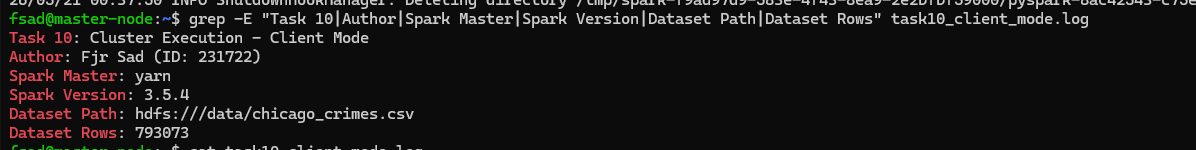

The complete terminal log is saved in GitHub under output/task10_client_mode.log.

## Task 11: Cluster Execution - Spark Submit

**Author: Fjr Sad (ID: 231722)**


**Spark Master:** yarn  
**Spark Version:** 3.5.4  
**Dataset Path:** hdfs:///data/chicago_crimes.csv  
**Original Dataset Rows:** 793073  
**Sampled Rows for ML:** 39534  

**Application ID:** application_1778738889964_0118  
**Final Status:** SUCCEEDED  

**Command used:**

```bash
spark-submit --master yarn --deploy-mode cluster m2_spark_ml.py 2>&1 | tee task11_spark_submit_output.log

**Output:**

```text
Spark Master: yarn
Spark Version: 3.5.4
Original row count: 793073
Sampled row count for ML: 39534

Model: Logistic Regression
AUC-ROC: 0.620330164552448
Accuracy: 0.7261081219574687
F1 Score: 0.6316050325008271
Precision: 0.696725923672566
Recall: 0.7261081219574687

Model: Random Forest
AUC-ROC: 0.8137701156452186
Accuracy: 0.8130924929541379
F1 Score: 0.7771865173014645
Precision: 0.8502960129925832
Recall: 0.8130924929541379

Model: GBT
AUC-ROC: 0.8287458759997957
Accuracy: 0.851652574942352
F1 Score: 0.836329108342923
Precision: 0.8620549792100882
Recall: 0.851652574942352
```

The spark-submit run finished successfully on YARN cluster mode. It loaded the full HDFS dataset, used a sampled set for ML training, and ran all three models: Logistic Regression, Random Forest, and GBT.

The complete terminal and YARN logs were saved in GitHub under:

```text
output/task11_spark_submit_output.log
output/task11_yarn_logs.log
output/task11_clean_output.log
```

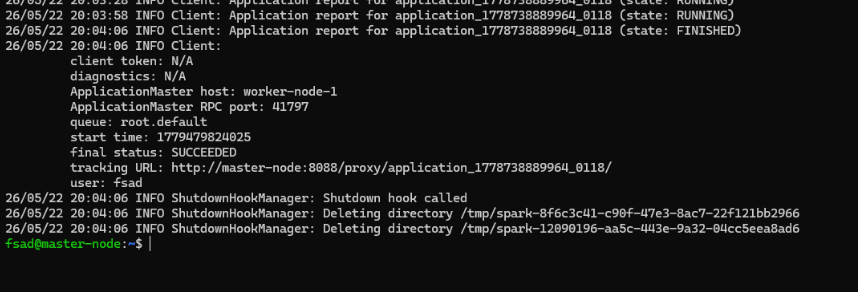

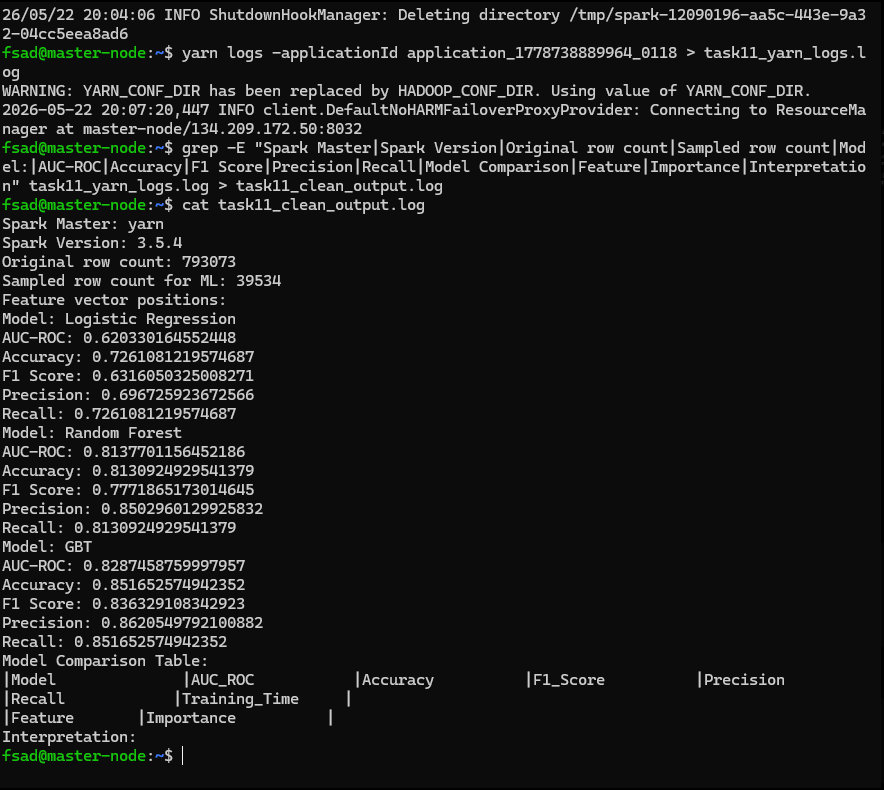